# Manchester Property Price Prediction Pipeline

This notebook loads the Manchester property dataset, preprocesses it, and trains a model to predict sale prices.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Inspect Data

In [2]:
df = pd.read_parquet('manchester_features.parquet')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset shape: (474144, 23)

Columns: ['postcode', 'tx_id', 'price', 'transfer_date', 'property_type', 'old_new', 'duration', 'town', 'district', 'borough', 'lat', 'lon', 'epc_rating', 'floor_area', 'co2_emissions', 'crime_count', 'dist_nearest_station_km', 'nearest_station_name', 'dist_nearest_school_km', 'nearest_school_name', 'nearest_school_ofsted', 'dist_nearest_supermarket_km', 'nearest_supermarket_name']

Missing values:
epc_rating       158707
floor_area       158707
co2_emissions    158707
dtype: int64


## 2. Preprocessing

In [3]:
# Drop columns we don't need
drop_cols = ['tx_id', 'postcode', 'transfer_date', 'nearest_station_name',
             'nearest_school_name', 'nearest_supermarket_name', 'nearest_school_ofsted']
df = df.drop(columns=drop_cols)

# Fill missing values
df['epc_rating'] = df['epc_rating'].fillna('Unknown')
df['floor_area'] = df['floor_area'].fillna(df['floor_area'].median())
df['co2_emissions'] = df['co2_emissions'].fillna(df['co2_emissions'].median())

print(f"Shape after dropping columns: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Shape after dropping columns: (474144, 16)
Remaining missing values: 0


## 3. Feature Encoding

In [4]:
categorical_cols = ['property_type', 'old_new', 'duration', 'town',
                    'district', 'borough', 'epc_rating']

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("Encoding complete.")
print(f"Dtypes:\n{df.dtypes}")

Encoding complete.
Dtypes:
price                            int64
property_type                    int64
old_new                          int64
duration                         int64
town                             int64
district                         int64
borough                          int64
lat                            float64
lon                            float64
epc_rating                       int64
floor_area                     float64
co2_emissions                  float64
crime_count                      int64
dist_nearest_station_km        float64
dist_nearest_school_km         float64
dist_nearest_supermarket_km    float64
dtype: object


## 4. Define Features and Target

In [5]:
# Define features and target — exclude price from X to avoid target leakage
X = df.drop(columns=['price']).copy()
y = df['price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {list(X.columns)}")

Features shape: (474144, 15)
Target shape: (474144,)
Feature columns: ['property_type', 'old_new', 'duration', 'town', 'district', 'borough', 'lat', 'lon', 'epc_rating', 'floor_area', 'co2_emissions', 'crime_count', 'dist_nearest_station_km', 'dist_nearest_school_km', 'dist_nearest_supermarket_km']


## 5. Scaling and Train/Test Split

In [6]:
# Split first, then fit scaler only on training data to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 331900, Test size: 142244


## 6. Train Model

In [7]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model training complete.")

Model training complete.


## 7. Evaluate Model

In [8]:
# BUG 2: mean_squared_error was never imported — this cell will crash
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: £{rmse:,.2f}")
print(f"MAE:  £{mae:,.2f}")
print(f"R²:   {r2:.4f}")

RMSE: £826,526.90
MAE:  £90,707.67
R²:   0.2756


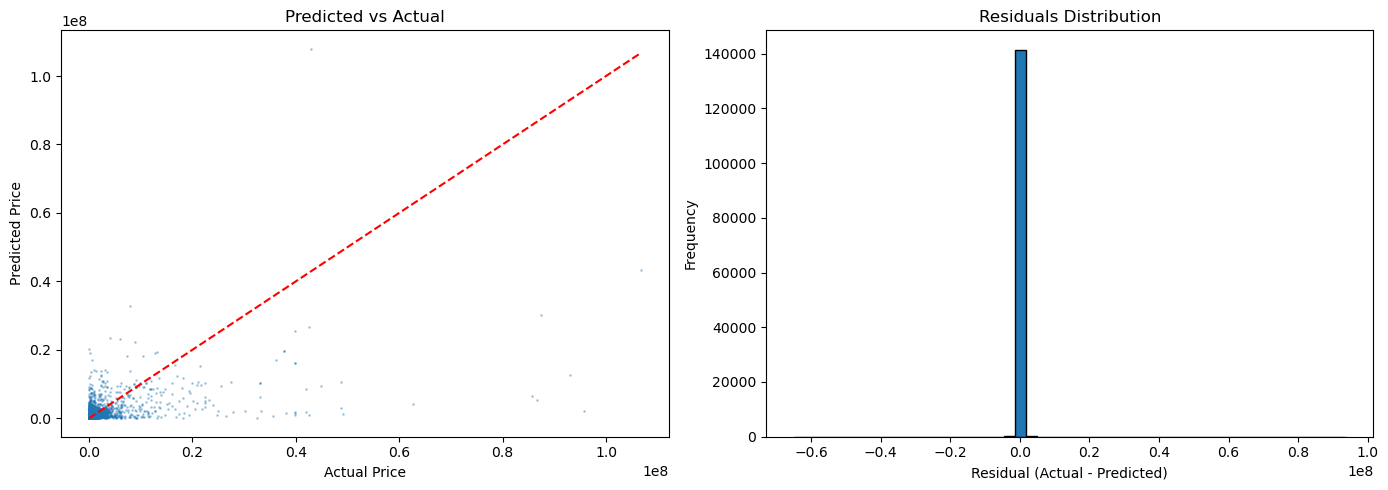

In [9]:
# Plot predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=1)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Predicted vs Actual')

residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.show()

## 8. Feature Importances

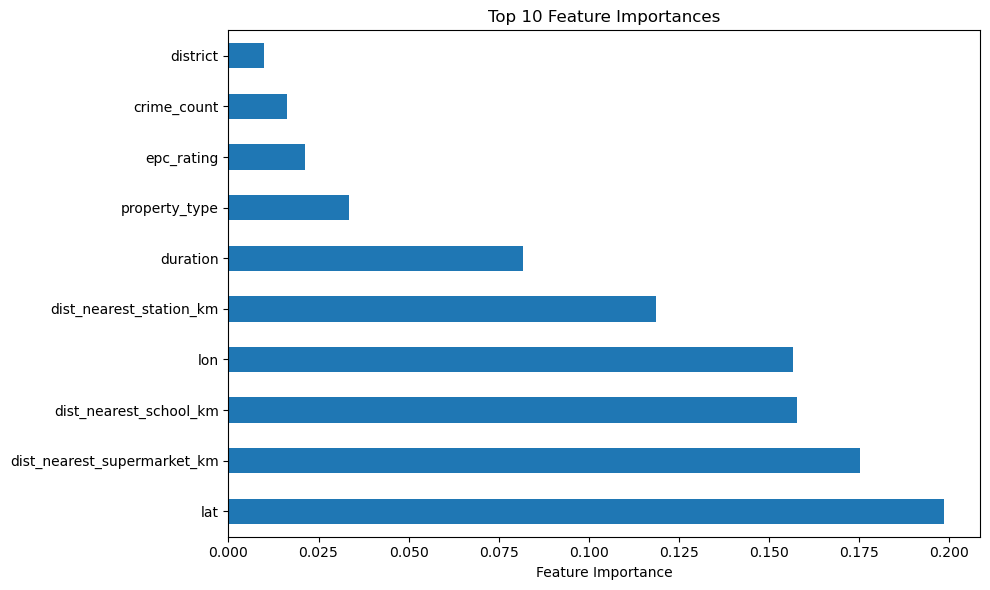

In [10]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_10.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()